# Predicting Customer Churn with Nori

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Synthefy/synthefy-nori/blob/main/examples/notebooks/nori-churn-prediction.ipynb)

This notebook reproduces the benchmark in the Synthefy article [Better Churn Prediction with Nori](https://synthefy.com/blog/nori-churn-prediction).

It uses the [UCI Iranian Churn dataset](https://doi.org/10.24432/C5JW3Z): 3,150 telecom subscribers, 13 numeric relationship, usage, and service fields aggregated over the first nine months, and churn measured at month 12. We keep every source field and add ten leak-safe rates and interactions, giving both models 23 inputs.

Nori treats binary churn as a continuous 0/1 regression target and returns a ranking score. PR-AUC is primary because 15.7% of customers churn. ROC-AUC and the complete ranking curves are reported alongside it.

## Setup

The default run evaluates five fixed stratified holdouts (seeds 42–46). Set `CHURN_BENCHMARK_SEEDS=42` for the faster reference split only. XGBoost searches the same 500 configurations used for the published result inside each context split; set `XGB_SEARCH_CONFIGS` lower while experimenting.

In [1]:
# Install only when the runtime does not already have Nori.
try:
    import synthefy_nori  # noqa: F401
except ImportError:
    %pip install -q "synthefy-nori[eval]" xgboost joblib ipywidgets

In [2]:
import os
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split
from synthefy_nori import NoriRegressor
from xgboost import XGBClassifier

TEST_SEEDS = [
    int(seed)
    for seed in os.environ.get("CHURN_BENCHMARK_SEEDS", "42,43,44,45,46").split(",")
]
XGB_SEARCH_CONFIGS = int(os.environ.get("XGB_SEARCH_CONFIGS", "500"))
XGB_JOBS = int(os.environ.get("XGB_JOBS", str(min(8, os.cpu_count() or 1))))
CHURN_DEVICE = os.environ.get("CHURN_DEVICE", "cpu")
DATA_URL = "https://archive.ics.uci.edu/static/public/563/iranian+churn+dataset.zip"

default_data_dir = "/content/iranian-churn" if "google.colab" in __import__("sys").modules else "/tmp/nori-iranian-churn"
data_dir = Path(os.environ.get("IRANIAN_CHURN_DATA_DIR", default_data_dir))
data_dir.mkdir(parents=True, exist_ok=True)
data_path = data_dir / "Customer Churn.csv"

if not data_path.exists():
    archive_path = data_dir / "iranian-churn.zip"
    print("Downloading the UCI Iranian Churn dataset...")
    urllib.request.urlretrieve(DATA_URL, archive_path)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extract("Customer Churn.csv", data_dir)

raw = pd.read_csv(data_path)
raw.columns = [" ".join(column.split()) for column in raw.columns]

print(f"Loaded {len(raw):,} labeled telecom subscribers.")
print(f"{raw.shape[1] - 1} numeric source fields")
print(f"{raw['Churn'].mean():.1%} churn rate")
display(raw.head())

Loaded 3,150 labeled telecom subscribers.
13 numeric source fields
15.7% churn rate


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


## Build a point-in-time customer table

Every source field is aggregated from the first nine months. The label records whether the subscriber has churned by month 12, so features precede the outcome by a three-month planning gap.

The 13 source fields cover relationship context, usage, and service experience. We add ten deterministic rates and interactions using only values already present in the same row. Both models receive the same unscaled 23-column table.

In [3]:
FEATURE_GROUPS = {
    "Relationship context": [
        "Subscription Length",
        "Charge Amount",
        "Tariff Plan",
        "Status",
        "Age",
        "Age Group",
        "Customer Value",
    ],
    "Usage": [
        "Seconds of Use",
        "Frequency of use",
        "Frequency of SMS",
        "Distinct Called Numbers",
    ],
    "Service experience": [
        "Call Failure",
        "Complains",
    ],
}

DERIVED_FEATURES = [
    "Average Call Duration",
    "Call Failure Rate",
    "Contact Diversity",
    "Total Communication Frequency",
    "SMS Share",
    "Seconds per Distinct Number",
    "Customer Value per Communication",
    "Customer Value per Second",
    "Complaint Failure Interaction",
    "Status Communication Interaction",
]


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return numerator / denominator.clip(lower=1)


def add_derived_features(source: pd.DataFrame) -> pd.DataFrame:
    result = source.copy()
    calls = source["Frequency of use"]
    sms = source["Frequency of SMS"]
    communication = calls + sms
    result["Average Call Duration"] = safe_ratio(source["Seconds of Use"], calls)
    result["Call Failure Rate"] = safe_ratio(source["Call Failure"], calls)
    result["Contact Diversity"] = safe_ratio(source["Distinct Called Numbers"], calls)
    result["Total Communication Frequency"] = communication
    result["SMS Share"] = safe_ratio(sms, communication)
    result["Seconds per Distinct Number"] = safe_ratio(
        source["Seconds of Use"], source["Distinct Called Numbers"]
    )
    result["Customer Value per Communication"] = safe_ratio(
        source["Customer Value"], communication
    )
    result["Customer Value per Second"] = safe_ratio(
        source["Customer Value"], source["Seconds of Use"]
    )
    result["Complaint Failure Interaction"] = source["Complains"] * source["Call Failure"]
    result["Status Communication Interaction"] = source["Status"] * communication
    return result.astype(np.float32)


source_features = raw.drop(columns=["Churn"]).apply(pd.to_numeric).astype(np.float32)
X = add_derived_features(source_features)
y = raw["Churn"].to_numpy(dtype=np.int8)
assert np.isfinite(X.to_numpy()).all()
assert np.isfinite(y).all()


def split_customer_data(seed: int):
    return train_test_split(
        X,
        y,
        train_size=0.8,
        random_state=seed,
        stratify=y,
    )


X_train_reference, X_test_reference, y_train_reference, y_test_reference = split_customer_data(
    TEST_SEEDS[0]
)
print(f"{len(X_train_reference):,} labeled context customers")
print(f"{len(X_test_reference):,} held-out test customers")
print(f"{X_train_reference.shape[1]} shared model inputs")
display(pd.Series(FEATURE_GROUPS, name="Raw columns by business meaning").to_frame())
display(pd.Series(DERIVED_FEATURES, name="Derived model inputs").to_frame())

2,520 labeled context customers
630 held-out test customers
23 shared model inputs


,Raw columns by business meaning
Relationship context,"[Subscription Length, Charge Amount, Tariff Pl..."
Usage,"[Seconds of Use, Frequency of use, Frequency o..."
Service experience,"[Call Failure, Complains]"


,Derived model inputs
0,Average Call Duration
1,Call Failure Rate
2,Contact Diversity
3,Total Communication Frequency
4,SMS Share
5,Seconds per Distinct Number
6,Customer Value per Communication
7,Customer Value per Second
8,Complaint Failure Interaction
9,Status Communication Interaction


## Add usage trends when timestamped activity is available

The UCI release contains nine-month totals, not event timestamps, so trend features cannot be computed for the published score. A production table should also compare recent and prior windows built strictly before each scoring date. The helper below turns those window totals into changes and ratios; append its output to the customer table before splitting by customer and time.

In [4]:
def add_usage_trends(customer_snapshots: pd.DataFrame) -> pd.DataFrame:
    """Add trend features after aggregating both windows before the scoring date."""
    result = customer_snapshots.copy()
    for metric in ["seconds_of_use", "calls", "sms"]:
        recent = result[f"{metric}_last_30d"]
        prior = result[f"{metric}_prior_30d"]
        result[f"{metric}_30d_change"] = recent - prior
        result[f"{metric}_30d_ratio"] = recent / prior.clip(lower=1)
    return result

## Nori produces a score; the threshold produces the retention decision

`fit()` stores each split's labeled context customers; it does not train a task-specific model. `predict()` returns a continuous score. Raw scores are used for ranking metrics, while clipped scores are used only when presenting a value as a probability-like churn score.

In [5]:
nori_runs = {}

for seed in TEST_SEEDS:
    X_train_raw, X_test_raw, y_train, y_test = split_customer_data(seed)
    print(f"Scoring Nori-30M for split seed {seed}...")
    nori = NoriRegressor(
        model="nori-30m",
        device=CHURN_DEVICE,
        memory_policy="exact",
    )
    nori.fit(X_train_raw.to_numpy(dtype=np.float32), y_train.astype(float))
    raw_score = np.asarray(
        nori.predict(X_test_raw.to_numpy(dtype=np.float32), output_type="mean")
    ).reshape(-1)
    nori_runs[seed] = {
        "X_test": X_test_raw,
        "y_test": y_test,
        "raw_score": raw_score,
        "PR-AUC": float(average_precision_score(y_test, raw_score)),
        "ROC-AUC": float(roc_auc_score(y_test, raw_score)),
    }

reference = nori_runs[TEST_SEEDS[0]]
RETENTION_THRESHOLD = 0.5
ranked_positions = np.argsort(reference["raw_score"])
preview_positions = ranked_positions[
    [0, len(ranked_positions) // 3, 2 * len(ranked_positions) // 3, -1]
]
decision_preview = reference["X_test"].iloc[preview_positions].copy()
decision_preview["churn_score"] = np.clip(
    reference["raw_score"][preview_positions], 0.0, 1.0
)
decision_preview["observed_churn"] = reference["y_test"][preview_positions]
decision_preview["prioritize_for_outreach"] = (
    decision_preview["churn_score"] >= RETENTION_THRESHOLD
)

display(decision_preview)
display(pd.DataFrame(
    {
        seed: {
            "PR-AUC": run["PR-AUC"],
            "ROC-AUC": run["ROC-AUC"],
        }
        for seed, run in nori_runs.items()
    }
).T.rename_axis("split seed"))

Scoring Nori-30M for split seed 42...


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Scoring Nori-30M for split seed 43...


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Scoring Nori-30M for split seed 44...


...

Mixed precision is not supported for CPU inference, so it has been automatically disabled


Scoring Nori-30M for split seed 46...


Mixed precision is not supported for CPU inference, so it has been automatically disabled


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,Total Communication Frequency,SMS Share,Seconds per Distinct Number,Customer Value per Communication,Customer Value per Second,Complaint Failure Interaction,Status Communication Interaction,churn_score,observed_churn,prioritize_for_outreach
2097,3.0,0.0,14.0,2.0,2547.0,39.0,24.0,17.0,3.0,1.0,...,63.0,0.380952,149.823532,3.165714,0.078304,0.0,63.0,0.000000,0,False
3046,11.0,0.0,16.0,0.0,8527.0,166.0,55.0,42.0,5.0,1.0,...,221.0,0.248869,203.023804,0.963326,0.024967,0.0,221.0,0.000000,0,False
1547,7.0,0.0,14.0,4.0,3148.0,49.0,45.0,32.0,3.0,1.0,...,94.0,0.478723,98.375000,3.275319,0.097802,0.0,94.0,0.002139,0,False
2126,14.0,1.0,37.0,0.0,3295.0,47.0,16.0,18.0,3.0,1.0,...,63.0,0.253968,183.055557,3.137778,0.059994,14.0,126.0,1.000000,1,True


,PR-AUC,ROC-AUC
split seed,,
42,0.986334,0.997527
43,0.984816,0.995939
44,0.980851,0.995473
45,0.960792,0.993000
46,0.982661,0.993009


## Compare with tuned XGBoost

For each held-out split, XGBoost receives the identical 23-column context table. Its configuration is selected by five-fold stratified cross-validation using context customers only. The held-out customers never participate in tuning.

In [6]:
def xgboost_parameter_grid(y_train: np.ndarray) -> dict[str, list[float | int]]:
    imbalance = float(np.sum(y_train == 0) / np.sum(y_train == 1))
    return {
        "n_estimators": [100, 200, 350, 500, 750, 1000],
        "max_depth": [2, 3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.02, 0.04, 0.06, 0.10, 0.15, 0.20],
        "subsample": [0.55, 0.70, 0.85, 1.0],
        "colsample_bytree": [0.55, 0.70, 0.85, 1.0],
        "min_child_weight": [1, 2, 4, 8, 12, 20],
        "gamma": [0.0, 0.02, 0.05, 0.10, 0.25, 0.50, 1.0],
        "reg_alpha": [0.0, 0.001, 0.01, 0.05, 0.10, 0.50, 1.0],
        "reg_lambda": [0.10, 0.50, 1.0, 2.0, 5.0, 10.0, 20.0],
        "scale_pos_weight": [1.0, np.sqrt(imbalance), imbalance],
    }


def make_xgboost(params: dict[str, object], seed: int) -> XGBClassifier:
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        n_jobs=1,
        random_state=seed,
        verbosity=0,
        **params,
    )


def score_xgboost_candidate(params, X_train, y_train, splits, seed):
    fold_scores = []
    for train_index, validation_index in splits:
        model = make_xgboost(params, seed)
        model.fit(X_train[train_index], y_train[train_index])
        score = model.predict_proba(X_train[validation_index])[:, 1]
        fold_scores.append(average_precision_score(y_train[validation_index], score))
    return float(np.mean(fold_scores)), params


xgboost_runs = {}
result_rows = []

for seed in TEST_SEEDS:
    X_train_raw, X_test_raw, y_train, y_test = split_customer_data(seed)
    X_train = X_train_raw.to_numpy(dtype=np.float32)
    X_test = X_test_raw.to_numpy(dtype=np.float32)
    candidates = list(ParameterSampler(
        xgboost_parameter_grid(y_train),
        n_iter=XGB_SEARCH_CONFIGS,
        random_state=seed,
    ))
    splits = list(StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    ).split(X_train, y_train))
    print(f"Searching {len(candidates)} XGBoost configurations for split seed {seed}...")
    search_results = Parallel(n_jobs=XGB_JOBS, prefer="threads", verbose=5)(
        delayed(score_xgboost_candidate)(params, X_train, y_train, splits, seed)
        for params in candidates
    )
    search_results.sort(key=lambda result: result[0], reverse=True)
    best_cv_pr_auc, best_params = search_results[0]

    xgboost = make_xgboost(best_params, seed)
    xgboost.fit(X_train, y_train)
    score = xgboost.predict_proba(X_test)[:, 1]
    xgboost_runs[seed] = {
        "score": score,
        "best_params": best_params,
        "best_cv_pr_auc": best_cv_pr_auc,
    }
    result_rows.append({
        "seed": seed,
        "Nori PR-AUC": nori_runs[seed]["PR-AUC"],
        "XGBoost PR-AUC": float(average_precision_score(y_test, score)),
        "Nori ROC-AUC": nori_runs[seed]["ROC-AUC"],
        "XGBoost ROC-AUC": float(roc_auc_score(y_test, score)),
    })

per_split = pd.DataFrame(result_rows).set_index("seed")
per_split["PR-AUC margin"] = per_split["Nori PR-AUC"] - per_split["XGBoost PR-AUC"]
per_split["ROC-AUC margin"] = per_split["Nori ROC-AUC"] - per_split["XGBoost ROC-AUC"]
display(per_split.style.format("{:.4f}"))

Searching 500 XGBoost configurations for split seed 42...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    1.3s


[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:    8.3s


[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   20.5s


...

[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   19.4s


[Parallel(n_jobs=8)]: Done 272 tasks      | elapsed:   34.2s


[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   52.7s


[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:  1.1min finished


,Nori PR-AUC,XGBoost PR-AUC,Nori ROC-AUC,XGBoost ROC-AUC,PR-AUC margin,ROC-AUC margin
seed,,,,,,
42,0.9863,0.9712,0.9975,0.9940,0.0151,0.0035
43,0.9848,0.9598,0.9959,0.9895,0.0250,0.0065
44,0.9809,0.9478,0.9955,0.9883,0.0330,0.0072
45,0.9608,0.9372,0.9930,0.9848,0.0236,0.0082
46,0.9827,0.9539,0.9930,0.9887,0.0288,0.0043


## Result

On the fixed seed-42 reference split, Nori reaches about **0.987 PR-AUC**, compared with **0.971** for tuned XGBoost. Across five fixed stratified holdouts, Nori averages about **0.979 ± 0.010**, compared with **0.954 ± 0.013** for XGBoost, a mean lead of **2.5 PR-AUC points**. Nori wins on every split.

The 23-column table is included to teach feature design, not to maximize Nori's score. Against the original 13-field version, Nori's mean PR-AUC falls by 0.002 while XGBoost's rises by 0.004. The benchmark keeps the engineered inputs and reports that result directly.

The curves below use the reference split; the summary table reports mean and sample standard deviation across all requested splits.

Mean PR-AUC margin: 0.0251
Nori wins: 5 / 5 splits


,PR-AUC mean,PR-AUC std,ROC-AUC mean,ROC-AUC std
Nori-30M,0.9791,0.0104,0.9950,0.0020
XGBoost (tuned),0.9540,0.0128,0.9891,0.0033


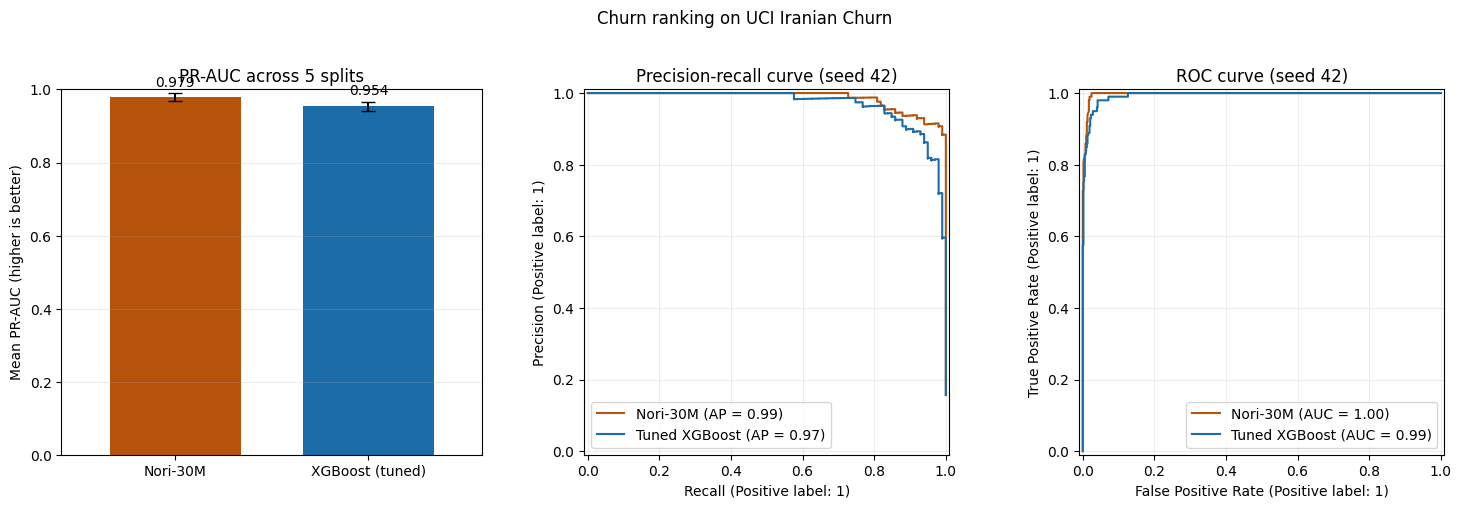

,Nori PR-AUC,XGBoost PR-AUC,Nori ROC-AUC,XGBoost ROC-AUC,PR-AUC margin,ROC-AUC margin
seed,,,,,,
42,0.986334,0.971231,0.997527,0.994008,0.015103,0.003519
43,0.984816,0.959832,0.995939,0.989452,0.024985,0.006487
44,0.980851,0.947849,0.995473,0.988263,0.033002,0.007210
45,0.960792,0.937205,0.993000,0.984801,0.023587,0.008199
46,0.982661,0.953905,0.993009,0.988748,0.028757,0.004261


In [7]:
summary = pd.DataFrame({
    "Nori-30M": {
        "PR-AUC mean": per_split["Nori PR-AUC"].mean(),
        "PR-AUC std": per_split["Nori PR-AUC"].std(ddof=1),
        "ROC-AUC mean": per_split["Nori ROC-AUC"].mean(),
        "ROC-AUC std": per_split["Nori ROC-AUC"].std(ddof=1),
    },
    "XGBoost (tuned)": {
        "PR-AUC mean": per_split["XGBoost PR-AUC"].mean(),
        "PR-AUC std": per_split["XGBoost PR-AUC"].std(ddof=1),
        "ROC-AUC mean": per_split["XGBoost ROC-AUC"].mean(),
        "ROC-AUC std": per_split["XGBoost ROC-AUC"].std(ddof=1),
    },
}).T

print(f"Mean PR-AUC margin: {per_split['PR-AUC margin'].mean():.4f}")
print(f"Nori wins: {(per_split['PR-AUC margin'] > 0).sum()} / {len(per_split)} splits")
display(summary.style.format("{:.4f}"))

reference_seed = TEST_SEEDS[0]
reference_y = nori_runs[reference_seed]["y_test"]
reference_nori = nori_runs[reference_seed]["raw_score"]
reference_xgboost = xgboost_runs[reference_seed]["score"]

figure, axes = plt.subplots(1, 3, figsize=(15, 4.8))
means = summary["PR-AUC mean"]
errors = summary["PR-AUC std"].fillna(0)
means.plot(
    kind="bar",
    yerr=errors,
    capsize=5,
    color=["#B45309", "#1B6CA8"],
    width=0.68,
    ax=axes[0],
)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Mean PR-AUC (higher is better)")
axes[0].set_title(f"PR-AUC across {len(per_split)} splits")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.22)
for container in axes[0].containers:
    if hasattr(container, "datavalues"):
        axes[0].bar_label(container, fmt="%.3f", padding=3)

PrecisionRecallDisplay.from_predictions(
    reference_y,
    reference_nori,
    name="Nori-30M",
    color="#B45309",
    ax=axes[1],
)
PrecisionRecallDisplay.from_predictions(
    reference_y,
    reference_xgboost,
    name="Tuned XGBoost",
    color="#1B6CA8",
    ax=axes[1],
)
axes[1].set_title(f"Precision-recall curve (seed {reference_seed})")
axes[1].grid(alpha=0.22)

RocCurveDisplay.from_predictions(
    reference_y,
    reference_nori,
    name="Nori-30M",
    color="#B45309",
    ax=axes[2],
)
RocCurveDisplay.from_predictions(
    reference_y,
    reference_xgboost,
    name="Tuned XGBoost",
    color="#1B6CA8",
    ax=axes[2],
)
axes[2].set_title(f"ROC curve (seed {reference_seed})")
axes[2].grid(alpha=0.22)

figure.suptitle("Churn ranking on UCI Iranian Churn", y=1.02)
plt.tight_layout()
plt.show()

per_split

## External context in production

The benchmark is point-in-time safe internally: features cover months 1–9 and churn is measured at month 12. It does **not** include per-row scoring dates, geography, or carrier identity, so it cannot support a defensible join to market offers, outages, or economic releases. A country-level value repeated across every row cannot change the customer ranking.

For production data, add external values only when they were published before each scoring date, then compare customer-only and enriched tables under the same time-based validation split.

## Sources and next steps

- [UCI Iranian Churn dataset](https://doi.org/10.24432/C5JW3Z) (CC BY 4.0)
- [Nori quickstart](https://docs.synthefy.com/nori/quickstart)
- [Synthefy Nori on GitHub](https://github.com/Synthefy/synthefy-nori)
- [Synthefy on Hugging Face](https://huggingface.co/Synthefy)